# 📊 Batch Normalization — A/B Tests
**TensorFlow + PyTorch**

| Variant | Description |
|---|---|
| **No Norm** | Baseline |
| **BatchNorm** | Normalize over batch dimension |
| **LayerNorm** | Normalize over feature dimension |
| **GroupNorm** | Normalize over channel groups |
| **InstanceNorm** | Normalize per sample per channel |
| **BN before vs after act** | Placement matters |
| **BN + high LR** | BN enables larger learning rates |

Same CNN, same CIFAR-10, only normalization changes.

## 1 — Setup

In [ ]:
import numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print('TF:', tf.__version__, ' PT:', torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
np.random.seed(42); tf.random.set_seed(42); torch.manual_seed(42)
EPOCHS = 20
BATCH  = 128

## 2 — TensorFlow: Normalization A/B Test

In [14]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()
x_tr = x_tr.astype('float32')/255.
x_te = x_te.astype('float32')/255.
y_tr = y_tr.squeeze(); y_te = y_te.squeeze()
AUTOTUNE = tf.data.AUTOTUNE
ds_tr = (tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
         .shuffle(50000, seed=42).batch(BATCH).prefetch(AUTOTUNE))
ds_te = (tf.data.Dataset.from_tensor_slices((x_te, y_te))
         .batch(BATCH).prefetch(AUTOTUNE))
print('Data ready')

Data ready


In [15]:
from tensorflow.keras import layers

def norm_layer_tf(x, norm_type):
    if norm_type == 'batch':      return layers.BatchNormalization()(x)
    elif norm_type == 'layer':    return layers.LayerNormalization()(x)
    elif norm_type == 'instance': return layers.LayerNormalization(axis=[1,2])(x)
    return x

def build_tf(norm_type='none', bn_after=False, lr=1e-3):
    inp = tf.keras.Input((32, 32, 3))
    x = inp
    for filters in [64, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        if not bn_after:
            x = norm_layer_tf(x, norm_type)
        x = layers.Activation('relu')(x)
        if bn_after:
            x = norm_layer_tf(x, norm_type)
        if filters != 64 or x.shape[1] == 32:
            pass
    x = layers.MaxPooling2D()(layers.Conv2D(64,3,padding='same',activation='relu')(inp))
    # simpler clean build
    x = inp
    for filters, pool in [(64,True),(64,False),(128,True)]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        if not bn_after: x = norm_layer_tf(x, norm_type)
        x = layers.Activation('relu')(x)
        if bn_after:     x = norm_layer_tf(x, norm_type)
        if pool:         x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(10, activation='softmax')(x)
    m = tf.keras.Model(inp, out)
    m.compile(tf.keras.optimizers.Adam(lr),
              'sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def train_tf(model, label):
    print(f'\nTraining [{label}]')
    tf.random.set_seed(42)
    h = model.fit(ds_tr, validation_data=ds_te, epochs=EPOCHS, verbose=0,
                  callbacks=[tf.keras.callbacks.LambdaCallback(
                      on_epoch_end=lambda e,l: print(
                          f'  ep {e+1:2d}  val={l["val_accuracy"]:.4f}')
                      if (e+1)%5==0 else None)])
    print(f'  best={max(h.history["val_accuracy"]):.4f}')
    return h

configs_tf = [
    ('No Norm',       dict(norm_type='none'),     1e-3),
    ('BatchNorm',     dict(norm_type='batch'),    1e-3),
    ('LayerNorm',     dict(norm_type='layer'),    1e-3),
    ('InstanceNorm',  dict(norm_type='instance'), 1e-3),
    ('BN after act',  dict(norm_type='batch', bn_after=True), 1e-3),
    ('BN + high LR',  dict(norm_type='batch'),   1e-2),
]

histories_tf = {}
for label, kwargs, lr in configs_tf:
    tf.random.set_seed(42)
    histories_tf[label] = train_tf(build_tf(**kwargs, lr=lr), label)


Training [No Norm]
  ep  5  val=0.7246
  ep 10  val=0.7347
  ep 15  val=0.7260
  ep 20  val=0.7330
  best=0.7432

Training [BatchNorm]
  ep  5  val=0.7391
  ep 10  val=0.7597
  ep 15  val=0.7329
  ep 20  val=0.7563
  best=0.7597

Training [LayerNorm]
  ep  5  val=0.6990
  ep 10  val=0.7446
  ep 15  val=0.7572
  ep 20  val=0.7497
  best=0.7616

Training [InstanceNorm]
  ep  5  val=0.7332
  ep 10  val=0.7479
  ep 15  val=0.7443
  ep 20  val=0.7492
  best=0.7558

Training [BN after act]
  ep  5  val=0.6915
  ep 10  val=0.7055
  ep 15  val=0.7206
  ep 20  val=0.7044
  best=0.7431

Training [BN + high LR]
  ep  5  val=0.3322
  ep 10  val=0.5778
  ep 15  val=0.6101
  ep 20  val=0.6145
  best=0.6256


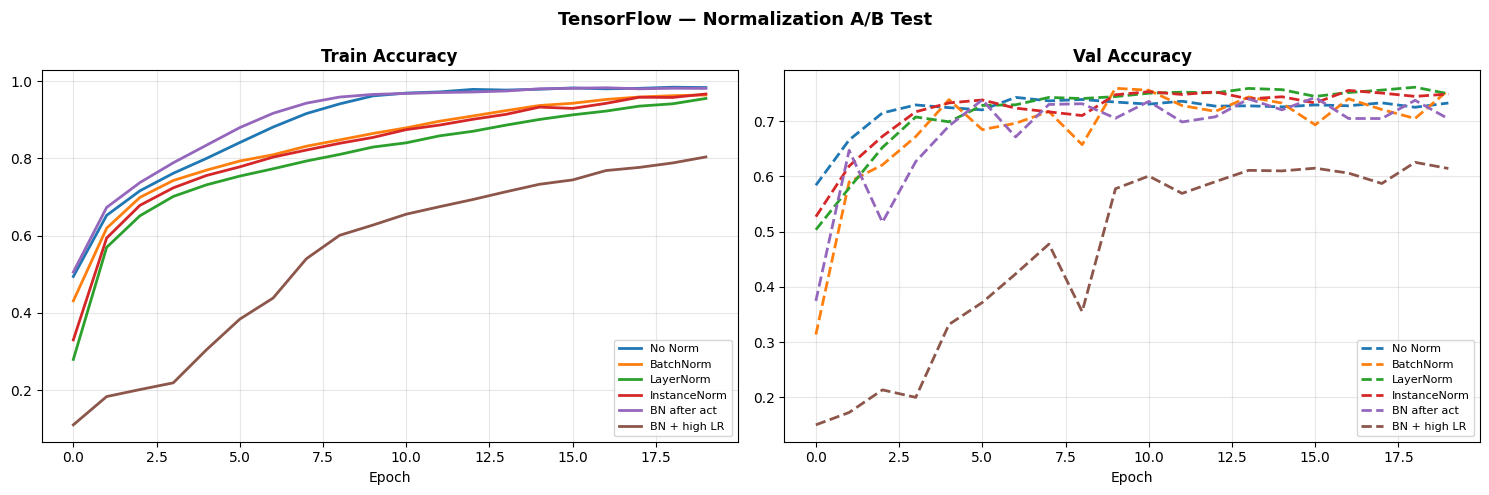


📊 TF Summary
Variant                 BestValAcc
-----------------------------------
No Norm                 0.7432
BatchNorm               0.7597
LayerNorm               0.7616
InstanceNorm            0.7558
BN after act            0.7431
BN + high LR            0.6256


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10.colors
for i, (label, h) in enumerate(histories_tf.items()):
    c = colors[i % 10]
    axes[0].plot(h.history['accuracy'],     color=c, label=label, lw=2)
    axes[1].plot(h.history['val_accuracy'], color=c, label=label, lw=2, ls='--')
for ax, t in zip(axes, ['Train Accuracy', 'Val Accuracy']):
    ax.set_title(t, fontweight='bold'); ax.legend(fontsize=8)
    ax.grid(alpha=.3); ax.set_xlabel('Epoch')
plt.suptitle('TensorFlow — Normalization A/B Test', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📊 TF Summary')
print(f'{"Variant":22s}  BestValAcc')
print('-'*35)
for label, h in histories_tf.items():
    print(f'{label:22s}  {max(h.history["val_accuracy"]):.4f}')

## 3 — Activation Distribution: With vs Without BN

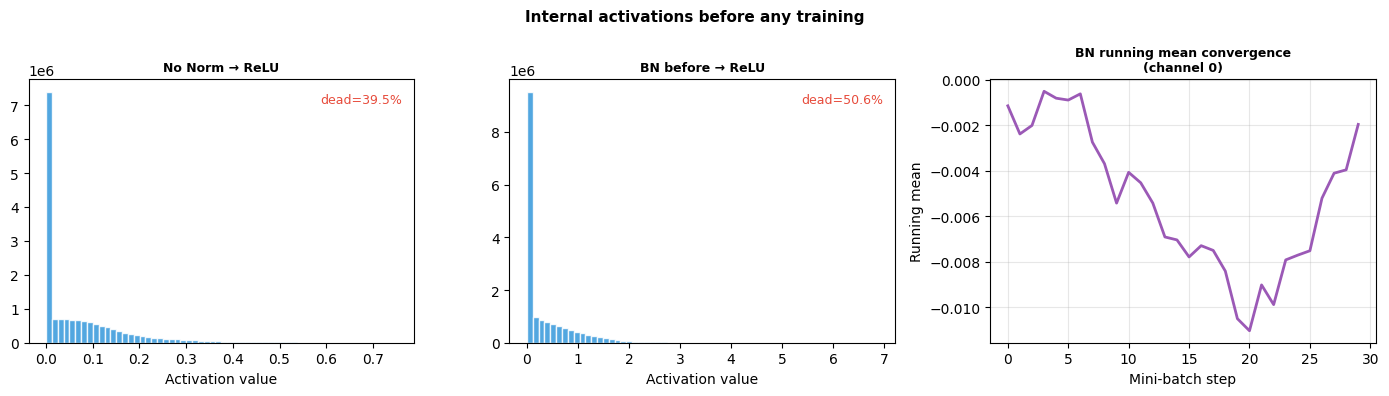

In [17]:
x_sample = tf.constant(x_tr[:256])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scenarios = [
    ('No Norm → ReLU',       False),
    ('BN before → ReLU',     True),
]
for ax, (title, use_bn) in zip(axes[:2], scenarios):
    tf.random.set_seed(42)
    conv = layers.Conv2D(64, 3, padding='same')
    bn   = layers.BatchNormalization()
    flat = tf.reshape(x_sample, [256, 32, 32, 3])
    out  = conv(flat)
    if use_bn: out = bn(out, training=True)
    out  = tf.nn.relu(out).numpy().flatten()
    ax.hist(out, bins=60, color='#3498db', alpha=0.85, edgecolor='white')
    dead = (out == 0).mean()
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Activation value')
    ax.text(0.97, 0.95, f'dead={dead:.1%}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color='#e74c3c' if dead > 0.3 else '#27ae60')

# show running mean/var convergence
ax = axes[2]
bn_layer = layers.BatchNormalization()
means = []
for _ in range(30):
    idx = np.random.choice(len(x_tr), 128)
    batch = tf.constant(x_tr[idx])
    out = tf.nn.relu(bn_layer(layers.Conv2D(64,3,padding='same')(batch), training=True))
    means.append(float(bn_layer.moving_mean[0]))
ax.plot(means, color='#9b59b6', lw=2)
ax.set_title('BN running mean convergence\n(channel 0)', fontweight='bold', fontsize=9)
ax.set_xlabel('Mini-batch step'); ax.set_ylabel('Running mean'); ax.grid(alpha=.3)

plt.suptitle('Internal activations before any training', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 4 — PyTorch: Normalization A/B Test

In [18]:
mean_pt = (0.4914, 0.4822, 0.4465)
std_pt  = (0.2023, 0.1994, 0.2010)
tfm = transforms.Compose([transforms.ToTensor(),
                           transforms.Normalize(mean_pt, std_pt)])
root = '/tmp/cifar'
tr_set = datasets.CIFAR10(root, train=True,  download=True,  transform=tfm)
te_set = datasets.CIFAR10(root, train=False, download=False, transform=tfm)
loader_tr = DataLoader(tr_set, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
loader_te = DataLoader(te_set, 256,   shuffle=False, num_workers=2, pin_memory=True)
print('PT data ready')

PT data ready


In [19]:
def make_norm_pt(norm_type, channels, num_groups=8):
    if norm_type == 'batch':    return nn.BatchNorm2d(channels)
    elif norm_type == 'layer':  return nn.GroupNorm(1, channels)
    elif norm_type == 'group':  return nn.GroupNorm(num_groups, channels)
    elif norm_type == 'instance': return nn.InstanceNorm2d(channels, affine=True)
    return nn.Identity()

class NormCNN(nn.Module):
    def __init__(self, norm_type='none', bn_after=False):
        super().__init__()
        self.bn_after = bn_after
        self.layers_list = nn.ModuleList()
        self.norms = nn.ModuleList()
        specs = [(3,64),(64,64),(64,128)]
        for in_c, out_c in specs:
            self.layers_list.append(nn.Conv2d(in_c, out_c, 3, padding=1))
            self.norms.append(make_norm_pt(norm_type, out_c))
        self.pool = nn.MaxPool2d(2)
        self.fc1  = nn.Linear(128*8*8, 256)
        self.fc2  = nn.Linear(256, 10)

    def forward(self, x):
        for i, (conv, norm) in enumerate(zip(self.layers_list, self.norms)):
            x = conv(x)
            if not self.bn_after: x = norm(x)
            x = torch.relu(x)
            if self.bn_after:     x = norm(x)
            if i in (0, 2):      x = self.pool(x)
        x = x.flatten(1)
        return self.fc2(torch.relu(self.fc1(x)))

def train_pt(model, name, lr=1e-3):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    tr_acc, va_acc = [], []
    print(f'\nTraining [{name}]')
    for ep in range(1, EPOCHS+1):
        model.train(); c, t = 0, 0
        for x, y in loader_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            with torch.no_grad():
                c += (model(x).argmax(1)==y).sum().item(); t += y.size(0)
        tr_acc.append(c/t)
        model.eval(); c, t = 0, 0
        with torch.no_grad():
            for x, y in loader_te:
                x, y = x.to(DEVICE), y.to(DEVICE)
                c += (model(x).argmax(1)==y).sum().item(); t += y.size(0)
        va_acc.append(c/t)
        if ep%5==0: print(f'  ep {ep:2d}  val={va_acc[-1]:.4f}')
    print(f'  best={max(va_acc):.4f}')
    return tr_acc, va_acc

configs_pt = [
    ('No Norm',       dict(norm_type='none'),               1e-3),
    ('BatchNorm',     dict(norm_type='batch'),              1e-3),
    ('LayerNorm',     dict(norm_type='layer'),              1e-3),
    ('GroupNorm',     dict(norm_type='group'),              1e-3),
    ('InstanceNorm',  dict(norm_type='instance'),           1e-3),
    ('BN after act',  dict(norm_type='batch', bn_after=True), 1e-3),
    ('BN + high LR',  dict(norm_type='batch'),              1e-2),
]

results_pt = {}
for label, kwargs, lr in configs_pt:
    torch.manual_seed(42)
    m = NormCNN(**kwargs).to(DEVICE)
    results_pt[label] = train_pt(m, label, lr=lr)


Training [No Norm]
  ep  5  val=0.7372
  ep 10  val=0.7312
  ep 15  val=0.7282
  ep 20  val=0.7304
  best=0.7471

Training [BatchNorm]
  ep  5  val=0.7564
  ep 10  val=0.7874
  ep 15  val=0.7786
  ep 20  val=0.7792
  best=0.7874

Training [LayerNorm]
  ep  5  val=0.7297
  ep 10  val=0.7643
  ep 15  val=0.7740
  ep 20  val=0.7698
  best=0.7773

Training [GroupNorm]
  ep  5  val=0.7242
  ep 10  val=0.7630
  ep 15  val=0.7675
  ep 20  val=0.7632
  best=0.7797

Training [InstanceNorm]
  ep  5  val=0.7455
  ep 10  val=0.7653
  ep 15  val=0.7678
  ep 20  val=0.7659
  best=0.7709

Training [BN after act]
  ep  5  val=0.7773
  ep 10  val=0.7652
  ep 15  val=0.7553
  ep 20  val=0.7673
  best=0.7783

Training [BN + high LR]
  ep  5  val=0.6289
  ep 10  val=0.6886
  ep 15  val=0.6904
  ep 20  val=0.6823
  best=0.6982


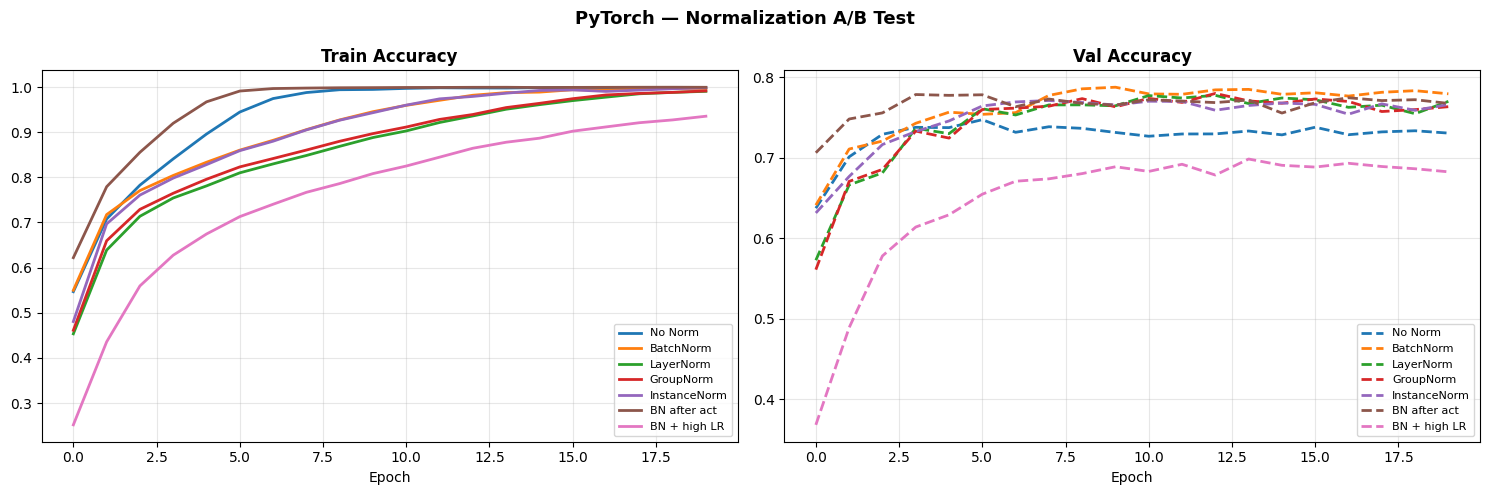


📊 PT Summary
Variant                 BestValAcc
-----------------------------------
No Norm                 0.7471
BatchNorm               0.7874
LayerNorm               0.7773
GroupNorm               0.7797
InstanceNorm            0.7709
BN after act            0.7783
BN + high LR            0.6982


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10.colors
for i, (label, (tr, va)) in enumerate(results_pt.items()):
    c = colors[i % 10]
    axes[0].plot(tr, color=c, label=label, lw=2)
    axes[1].plot(va, color=c, label=label, lw=2, ls='--')
for ax, t in zip(axes, ['Train Accuracy', 'Val Accuracy']):
    ax.set_title(t, fontweight='bold'); ax.legend(fontsize=8)
    ax.grid(alpha=.3); ax.set_xlabel('Epoch')
plt.suptitle('PyTorch — Normalization A/B Test', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📊 PT Summary')
print(f'{"Variant":22s}  BestValAcc')
print('-'*35)
for label, (tr, va) in results_pt.items():
    print(f'{label:22s}  {max(va):.4f}')

## 5 — Common Bug: BN in train() mode at inference

In [22]:
torch.manual_seed(42)
m_bug = NormCNN(norm_type='batch').to(DEVICE)

# Temporarily set EPOCHS for this specific training run
original_epochs = EPOCHS
EPOCHS = 5
train_pt(m_bug, 'BN model (bug demo)')
EPOCHS = original_epochs # Restore original EPOCHS value

def eval_acc(model, train_mode):
    model.train() if train_mode else model.eval()
    c, t = 0, 0
    with torch.no_grad():
        for x, y in loader_te:
            x, y = x.to(DEVICE), y.to(DEVICE)
            c += (model(x).argmax(1)==y).sum().item(); t += y.size(0)
    return c/t

acc_eval  = eval_acc(m_bug, train_mode=False)
acc_train = eval_acc(m_bug, train_mode=True)
print(f'\n model.eval()  → {acc_eval:.4f}  correct')
print(f'  model.train() → {acc_train:.4f}  BUG — uses batch stats instead of running stats')
print(f'  Difference     {acc_eval - acc_train:+.4f}')
print('\n Always call model.eval() before inference!')


Training [BN model (bug demo)]
  ep  5  val=0.7616
  best=0.7616

 model.eval()  → 0.7616  correct
  model.train() → 0.7703  BUG — uses batch stats instead of running stats
  Difference     -0.0087

 Always call model.eval() before inference!


## 6 — Batch Size Sensitivity: BN vs GroupNorm

  bs=  8  batch  best=0.7762
  bs=  8  group  best=0.7631
  bs= 32  batch  best=0.7933
  bs= 32  group  best=0.7767
  bs=128  batch  best=0.7815
  bs=128  group  best=0.7766


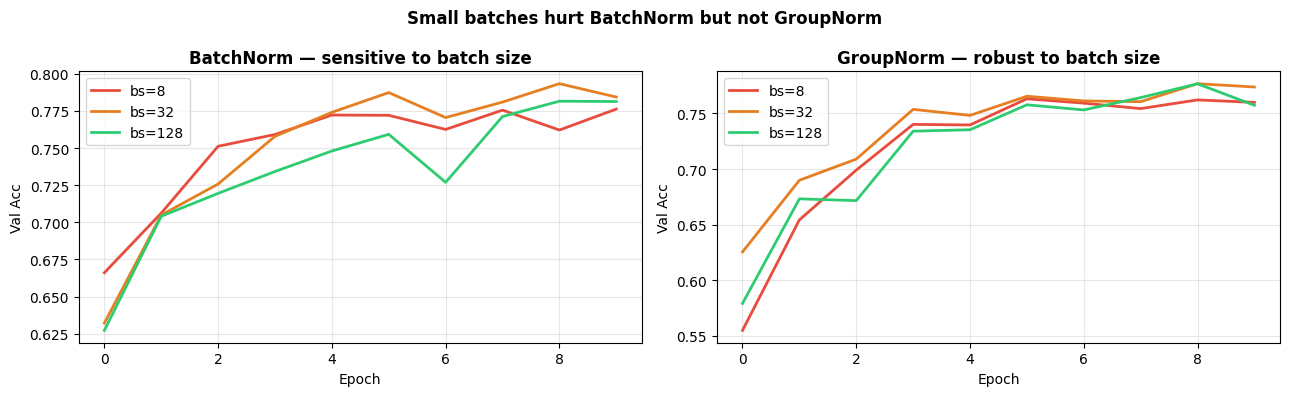

In [24]:
batch_sizes = [8, 32, 128]
bn_res, gn_res = {}, {}

for bs in batch_sizes:
    loader_bs = DataLoader(tr_set, bs, shuffle=True, num_workers=2, pin_memory=True)
    for norm, store in [('batch', bn_res), ('group', gn_res)]:
        torch.manual_seed(42)
        m = NormCNN(norm_type=norm).to(DEVICE)
        opt = torch.optim.Adam(m.parameters())
        crit = nn.CrossEntropyLoss()
        va_list = []
        for ep in range(10):
            m.train()
            for x, y in loader_bs:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad(); crit(m(x), y).backward(); opt.step()
            m.eval(); c, t = 0, 0
            with torch.no_grad():
                for x, y in loader_te:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    c += (m(x).argmax(1)==y).sum().item(); t += y.size(0)
            va_list.append(c/t)
        store[bs] = va_list
        print(f'  bs={bs:3d}  {norm:5s}  best={max(va_list):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for bs, color in zip(batch_sizes, ['#e74c3c','#e67e22','#2ecc71']):
    axes[0].plot(bn_res[bs], color=color, label=f'bs={bs}', lw=2)
    axes[1].plot(gn_res[bs], color=color, label=f'bs={bs}', lw=2)
axes[0].set_title('BatchNorm — sensitive to batch size', fontweight='bold')
axes[1].set_title('GroupNorm — robust to batch size', fontweight='bold')
for ax in axes:
    ax.legend(); ax.grid(alpha=.3); ax.set_xlabel('Epoch'); ax.set_ylabel('Val Acc')
plt.suptitle('Small batches hurt BatchNorm but not GroupNorm', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 7 — Quick-Reference Cheat Sheet

In [23]:
print('''
Normalization Cheat-Sheet
─────────────────────────────────────────────────────────────────────
  BatchNorm     CNNs, large batches (bs>=16), enables higher LR
                Avoid: small batches, RNNs, online learning

  LayerNorm     Transformers, NLP, RNNs — batch-size independent
                Avoid: CNNs (BatchNorm usually better there)

  GroupNorm     Object detection / segmentation (small bs forced)
                Good when bs < 16 and BatchNorm stats are noisy

  InstanceNorm  Style transfer, GANs — removes style, keeps content
                Avoid: classification (throws away useful statistics)

Placement rule (default):
  Conv → BN → ReLU   (normalize pre-activation)

Key practical rules:
  1. Always model.eval() at inference  (BN switches to running stats)
  2. BatchNorm lets you use 5-10x larger LR safely
  3. For bs < 16  →  GroupNorm or LayerNorm
  4. For RNNs / Transformers  →  LayerNorm
  5. Biases before BN are redundant (BN has its own beta shift)
─────────────────────────────────────────────────────────────────────
''')


Normalization Cheat-Sheet
─────────────────────────────────────────────────────────────────────
  BatchNorm     CNNs, large batches (bs>=16), enables higher LR
                Avoid: small batches, RNNs, online learning

  LayerNorm     Transformers, NLP, RNNs — batch-size independent
                Avoid: CNNs (BatchNorm usually better there)

  GroupNorm     Object detection / segmentation (small bs forced)
                Good when bs < 16 and BatchNorm stats are noisy

  InstanceNorm  Style transfer, GANs — removes style, keeps content
                Avoid: classification (throws away useful statistics)

Placement rule (default):
  Conv → BN → ReLU   (normalize pre-activation)

Key practical rules:
  1. Always model.eval() at inference  (BN switches to running stats)
  2. BatchNorm lets you use 5-10x larger LR safely
  3. For bs < 16  →  GroupNorm or LayerNorm
  4. For RNNs / Transformers  →  LayerNorm
  5. Biases before BN are redundant (BN has its own beta shift)
─────────────